In [2]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn

  Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl (12.5 MB)
Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl (9.9 MB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.5 MB 8.0 MB/s eta 0:00:01
   ---------------------- -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Mariem\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [4]:
# Force reinstall with pip
import subprocess
import sys

packages = ['numpy', 'pandas', 'matplotlib', 'seaborn']

for package in packages:
    print(f"Installing {package}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", package])
    print(f" {package} done\n")
    

Installing numpy...
✓ numpy done

Installing pandas...
✓ pandas done

Installing matplotlib...
✓ matplotlib done

Installing seaborn...
✓ seaborn done



In [5]:
# Install directly to the Python Jupyter is using
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", 
                       "--upgrade", "numpy", "pandas", "matplotlib", "seaborn"])

0

In [6]:
# Complete verification
import sys
import subprocess

print("="*50)
print("CHECKING JUPYTER ENVIRONMENT")
print("="*50)

print(f"\nPython executable: {sys.executable}")

# Try imports one by one
for package in ['numpy', 'pandas', 'matplotlib', 'seaborn']:
    try:
        exec(f"import {package}")
        version = eval(f"{package}.__version__")
        print(f" {package}: {version}")
    except ImportError:
        print(f" {package}: NOT FOUND - installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

print("\n" + "="*50)
print("Setup complete! You can now run the lab code.")
print("="*50)

CHECKING JUPYTER ENVIRONMENT

Python executable: C:\Users\Mariem\AppData\Local\Python\pythoncore-3.14-64\python.exe
✅ numpy: 2.4.6
✅ pandas: 3.0.3
✅ matplotlib: 3.11.0
✅ seaborn: 0.13.2

✓ Setup complete! You can now run the lab code.


1. Setup and Imports

In [7]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

2. The Abstract Problem Interface

In [8]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

3. The Node Class

In [9]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

4. Helper Functions

In [10]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

5. Implementing the Grid Search Problem

In [21]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    # TODO 1: returning True if state is equal to the goal state:
    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    # TODO 2: returning a list of legal action names:
    # Steps to take:
    # 1. Creating an empty list called legal_actions
    # 2. For each action in MOVES:
    #       a. Compute the neighbour cell
    #       b. Check that it is in bounds
    #       c. Check that it is free
    #       d. If valid, add the action name to legal_actions
    # 3. Returning the legal_actions
    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []
        row, col = state
        
        for action, (dr, dc) in MOVES.items():
            next_state = (row + dr, col + dc)
            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)
        
        return legal_actions

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    # TODO 3: returning the next state after applying action to state:
    # Hint: dr, dc = MOVES[action]
    # return (row + dr, col + dc)
    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    # TODO 4: In this lab, each valid move has a cost of 1:
    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1
        

#5.1 Self-Check for GridProblem

test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed!")

    

GridProblem self-check passed!


6. Sample Drone Map

In [14]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

7. Visualisation Helper

In [15]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

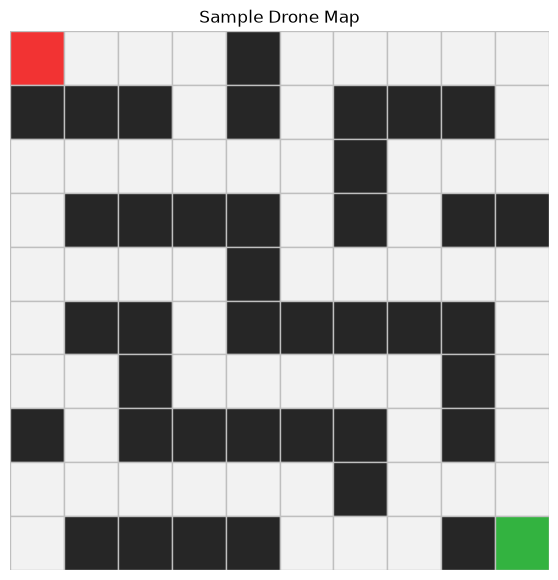

In [16]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

8. The Shared expand Method

In [22]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:implementing the AIMA-style EXPAND(problem, node):
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state  # for getting the current state from the node
        
        for action in problem.actions(s):  # Looping through all legal actions
            s_prime = problem.result(s, action)  # to get to the next state
            cost = node.path_cost + problem.action_cost(s, action, s_prime)  # Calculating the new cost
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)  # Creating and returning the child node

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

9. Breadth-First Search (BFS)

In [23]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:implementing the BFS graph search using a FIFO queue:
        # Step 1: Creating the initial node from problem.initial_state()
        initial_node = Node(problem.initial_state())
        nodes_expanded = 0
        max_frontier_size = 0
        
        # Step 2: verifying if the initial state is the goal, and returning success if it is the case
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial_node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=1
            )
        
        # Step 3: Creating a deque frontier and adding the initial node
        from collections import deque
        frontier = deque([initial_node])
        
        # Step 4: Creating a reached set and adding the initial state
        reached = {problem.initial_state()}
        max_frontier_size = max(max_frontier_size, len(frontier))
        
        # Step 5: verifying if the frontier is not empty using While
        while frontier:
            # a. pop from the LEFT of the deque (FIFO)
            node = frontier.popleft()
            # b. increment nodes_expanded
            nodes_expanded += 1
            # c. expand the node
            for child in self.expand(problem, node):
                # d.i. if child is goal, return success
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )
                # d.ii. if child.state is not in reached
                if child.state not in reached:
                    # add child.state to reached
                    reached.add(child.state)
                    # append child to frontier (add to back of queue)
                    frontier.append(child)
                    # e. update max_frontier_size
                    max_frontier_size = max(max_frontier_size, len(frontier))
        
        # Step 6: Returning failure if no solution is found
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

In [24]:
##An example to test:
# Create sample grid
sample_grid = [
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0],
]

problem = GridProblem(sample_grid, start=(0, 0), goal=(2, 2))

# Run BFS
bfs = BreadthFirstSearch()
result = bfs.search(problem)

print(f"Status: {result.status}")
print(f"Solution depth: {result.solution_depth}")
print(f"Nodes expanded: {result.nodes_expanded}")
print(f"Max frontier size: {result.max_frontier_size}")
print(f"Path: {result.path}")

Status: success
Solution depth: 4
Nodes expanded: 6
Max frontier size: 2
Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2)]


10. Depth-First Search (DFS)

In [26]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7: implementing DFS graph search using a stack:
        # Step 1: Creating the initial node
        initial_node = Node(problem.initial_state())
        nodes_expanded = 0
        max_frontier_size = 0
        
        # Step 2: searching for the initial state and finding if it is the goal, and returning success if it is the case
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial_node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=1
            )
        
        # Step 3: Using a Python list as the stack frontier (LIFO)
        frontier = [initial_node]
        
        # Step 4: Using a reached set
        reached = {problem.initial_state()}
        max_frontier_size = max(max_frontier_size, len(frontier))
        
        # Step 5: While frontier is not empty
        while frontier:
            # a. pop from the end of the list (LIFO - most recent node)
            node = frontier.pop()
            # b. increment nodes_expanded
            nodes_expanded += 1
            # c. expand the node
            # Note: Reverse children to explore in the same order as MOVES
            children = list(self.expand(problem, node))
            # d. add unreached children to the stack
            for child in reversed(children):  # Reverse for consistent order
                # Check if child is goal
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )
                # If child state not visited yet
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)  # Push onto stack
                    # e. update max_frontier_size
                    max_frontier_size = max(max_frontier_size, len(frontier))
        # Return failure if no solution found
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

#Example to test:  creating a sample grid
sample_grid = [
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0],
]

problem = GridProblem(sample_grid, start=(0, 0), goal=(2, 2))

# Run DFS
dfs = DepthFirstSearch()
result = dfs.search(problem)

print(f"Status: {result.status}")
print(f"Solution depth: {result.solution_depth}")
print(f"Nodes expanded: {result.nodes_expanded}")
print(f"Max frontier size: {result.max_frontier_size}")
print(f"Path: {result.path}")

Status: success
Solution depth: 4
Nodes expanded: 4
Max frontier size: 2
Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2)]


11. Depth-Limited Search (DLS)

In [28]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:implementing a recursive depth-limited search:
        # Step 1: If node.state is goal, return (node, "success")
        if problem.is_goal(node.state):
            return (node, "success")
    
        # Step 2: Else if node.depth >= limit, return (None, "cutoff")
        elif node.depth >= limit:
            return (None, "cutoff")
        
        # Step 3: Otherwise
        else:
            # a. increment metrics["nodes_expanded"]
            metrics["nodes_expanded"] += 1
            # b. set cutoff_occurred = False
            cutoff_occurred = False
            # c. for each child in expand(problem, node)
            for child in self.expand(problem, node):
                # i. skip the child if child.state already appears on the current path
                if state_is_on_path(node, child.state):
                    continue
                # ii. update max_stack_size
                new_stack_size = current_stack_size + 1
                metrics["max_stack_size"] = max(metrics["max_stack_size"], new_stack_size)
                # iii. recursively call _recursive_dls on the child
                result, status = self._recursive_dls(
                    problem=problem,
                    node=child,
                    limit=limit,
                    metrics=metrics,
                    current_stack_size=new_stack_size,
                )
                # iv. if result is "success", return success immediately
                if status == "success":
                    return (result, "success")
                
                # v. if result is "cutoff", set cutoff_occurred = True
                elif status == "cutoff":
                    cutoff_occurred = True
            
            # d. after all children
            if cutoff_occurred:
                return (None, "cutoff")
            else:
                return (None, "failure")

#Example for testing
# Create a simple grid
test_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

# Test with different limits
dls = DepthLimitedSearch()

print("=== DLS with limit=1 (too small) ===")
result = dls.search(problem, limit=1)
print(f"Status: {result.status}")
print(f"Solution: {result.solution}")
print(f"Nodes expanded: {result.nodes_expanded}")

print("\n=== DLS with limit=4 (should find goal) ===")
result = dls.search(problem, limit=4)
print(f"Status: {result.status}")
print(f"Solution depth: {result.solution_depth}")
print(f"Path: {result.path}")
print(f"Nodes expanded: {result.nodes_expanded}")

print("\n=== DLS with limit=10 (more than enough) ===")
result = dls.search(problem, limit=10)
print(f"Status: {result.status}")
print(f"Solution depth: {result.solution_depth}")
print(f"Nodes expanded: {result.nodes_expanded}")

=== DLS with limit=1 (too small) ===
Status: cutoff
Solution: None
Nodes expanded: 1

=== DLS with limit=4 (should find goal) ===
Status: success
Solution depth: 4
Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2)]
Nodes expanded: 4

=== DLS with limit=10 (more than enough) ===
Status: success
Solution depth: 8
Nodes expanded: 8


12. Iterative Deepening Search (IDS)

In [29]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:implementing IDS by repeatedly running DLS from limit 0 to max_depth:
        # 1. Keep a list called iteration_log
        iteration_log = []
        
        # 2. Accumulate total nodes expanded across all DLS iterations
        total_nodes_expanded = 0
        
        # 3. Track the maximum stack size seen in any DLS run
        max_stack_size_overall = 0
        
        # Create a DepthLimitedSearch object to use for each iteration
        dls = DepthLimitedSearch()
        
        # Loop through increasing depth limits from 0 to max_depth
        for limit in range(max_depth + 1):
            # Run DLS with current limit
            result = dls.search(problem, limit=limit)
            
            # Record the limit and status in the iteration log
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
                "max_stack_size": result.max_frontier_size,
            })
            
            # Accumulate total nodes expanded
            total_nodes_expanded += result.nodes_expanded
            
            # Track maximum stack size
            max_stack_size_overall = max(max_stack_size_overall, result.max_frontier_size)
            
            # 4. If a DLS run returns success, return a SearchResult for IDS
            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size_overall,
                    reached_count=0,
                    limit=None,
                    iterations=iteration_log,
                )
            
            # 5. If a DLS run returns failure, IDS can stop early and return failure
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size_overall,
                    reached_count=0,
                    limit=None,
                    iterations=iteration_log,
                )
            
            # If status is "cutoff", continue to next limit
            
            # Optional: 
            print(f"  Limit {limit}: {result.status} (expanded {result.nodes_expanded} nodes)")
        
        # 6. If all limits return cutoff up to max_depth, return cutoff
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size_overall,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log,
        )

#An example to test
# Create a simple grid
test_grid = [
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0],
]

problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

# Run IDS
ids = IterativeDeepeningSearch()
result = ids.search(problem, max_depth=10)

print("\n=== IDS Results ===")
print(f"Status: {result.status}")
print(f"Solution depth: {result.solution_depth}")
print(f"Path: {result.path}")
print(f"Total nodes expanded: {result.nodes_expanded}")
print(f"Max stack size: {result.max_frontier_size}")

print("\n=== Iteration Log ===")
for iteration in result.iterations:
    print(f"  Limit {iteration['limit']}: {iteration['status']} (expanded {iteration['nodes_expanded']} nodes)")

  Limit 0: cutoff (expanded 0 nodes)
  Limit 1: cutoff (expanded 1 nodes)
  Limit 2: cutoff (expanded 3 nodes)
  Limit 3: cutoff (expanded 5 nodes)

=== IDS Results ===
Status: success
Solution depth: 4
Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2)]
Total nodes expanded: 13
Max stack size: 5

=== Iteration Log ===
  Limit 0: cutoff (expanded 0 nodes)
  Limit 1: cutoff (expanded 1 nodes)
  Limit 2: cutoff (expanded 3 nodes)
  Limit 3: cutoff (expanded 5 nodes)
  Limit 4: success (expanded 4 nodes)


13. Run the Algorithms on the Sample Map

In [5]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}

class Problem(ABC):
    @abstractmethod
    def initial_state(self): pass
    @abstractmethod
    def is_goal(self, state): pass
    @abstractmethod
    def actions(self, state): pass
    @abstractmethod
    def result(self, state, action): pass
    @abstractmethod
    def action_cost(self, state, action, next_state): pass

@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0
    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1

@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None
    @property
    def path(self):
        if self.solution is None: return None
        path = []
        node = self.solution
        while node is not None:
            path.append(node.state)
            node = node.parent
        path.reverse()
        return path
    @property
    def solution_depth(self):
        return self.solution.depth if self.solution else None
    @property
    def solution_cost(self):
        return self.solution.path_cost if self.solution else None

def state_is_on_path(node, state):
    while node is not None:
        if node.state == state:
            return True
        node = node.parent
    return False

def show_results(results):
    data = []
    for r in results:
        data.append({
            "Algorithm": r.algorithm,
            "Status": r.status,
            "Limit": r.limit,
            "Solution depth": r.solution_depth,
            "Solution cost": r.solution_cost,
            "Nodes expanded": r.nodes_expanded,
            "Max frontier/stack": r.max_frontier_size,
            "Reached states": r.reached_count,
        })
    return pd.DataFrame(data)

def plot_path(grid, start=None, goal=None, path=None, title="Grid Map"):
    arr = np.array(grid)
    height, width = arr.shape
    path_set = set(path) if path is not None else set()
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)
    for row in range(height):
        for col in range(width):
            state = (row, col)
            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)
            rect = patches.Rectangle((col, row), 1, 1, linewidth=1, edgecolor=(0.75,0.75,0.75), facecolor=fill)
            ax.add_patch(rect)
    plt.show()

class GridProblem(Problem):
    def __init__(self, grid, start, goal):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])
    def initial_state(self):
        return self.start
    def is_goal(self, state):
        return state == self.goal
    def in_bounds(self, state):
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols
    def is_free(self, state):
        row, col = state
        return self.grid[row][col] == 0
    def actions(self, state):
        legal_actions = []
        row, col = state
        for action, (dr, dc) in MOVES.items():
            next_state = (row + dr, col + dc)
            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)
        return legal_actions
    def result(self, state, action):
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)
    def action_cost(self, state, action, next_state):
        return 1

class SearchAlgorithm(ABC):
    def expand(self, problem, node):
        s = node.state
        for action in problem.actions(s):
            sp = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, sp)
            yield Node(state=sp, parent=node, action=action, path_cost=cost)
    @abstractmethod
    def search(self, problem):
        pass

class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem):
        algorithm = "BFS"
        initial = Node(problem.initial_state())
        if problem.is_goal(initial.state):
            return SearchResult(algorithm=algorithm, status="success", solution=initial, nodes_expanded=0, max_frontier_size=1, reached_count=1)
        frontier = deque([initial])
        reached = {problem.initial_state()}
        nodes_expanded = 0
        max_frontier = 1
        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1
            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(algorithm=algorithm, status="success", solution=child, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier, reached_count=len(reached))
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier = max(max_frontier, len(frontier))
        return SearchResult(algorithm=algorithm, status="failure", solution=None, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier, reached_count=len(reached))

class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem):
        algorithm = "DFS"
        initial = Node(problem.initial_state())
        if problem.is_goal(initial.state):
            return SearchResult(algorithm=algorithm, status="success", solution=initial, nodes_expanded=0, max_frontier_size=1, reached_count=1)
        frontier = [initial]
        reached = {problem.initial_state()}
        nodes_expanded = 0
        max_frontier = 1
        while frontier:
            node = frontier.pop()
            nodes_expanded += 1
            children = list(self.expand(problem, node))
            for child in reversed(children):
                if problem.is_goal(child.state):
                    return SearchResult(algorithm=algorithm, status="success", solution=child, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier, reached_count=len(reached))
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier = max(max_frontier, len(frontier))
        return SearchResult(algorithm=algorithm, status="failure", solution=None, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier, reached_count=len(reached))

class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem, limit=10):
        algorithm = "DLS"
        initial = Node(problem.initial_state())
        metrics = {"nodes_expanded": 0, "max_stack_size": 1}
        solution, status = self._recursive(problem, initial, limit, metrics, 1)
        return SearchResult(algorithm=algorithm, status=status, solution=solution, nodes_expanded=metrics["nodes_expanded"], max_frontier_size=metrics["max_stack_size"], reached_count=0, limit=limit)
    def _recursive(self, problem, node, limit, metrics, stack_size):
        if problem.is_goal(node.state):
            return node, "success"
        if node.depth >= limit:
            return None, "cutoff"
        metrics["nodes_expanded"] += 1
        cutoff = False
        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue
            new_size = stack_size + 1
            metrics["max_stack_size"] = max(metrics["max_stack_size"], new_size)
            result, status = self._recursive(problem, child, limit, metrics, new_size)
            if status == "success":
                return result, "success"
            if status == "cutoff":
                cutoff = True
        return (None, "cutoff") if cutoff else (None, "failure")

class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem, max_depth=50):
        algorithm = "IDS"
        dls = DepthLimitedSearch()
        total_expanded = 0
        max_stack = 0
        iterations = []
        for limit in range(max_depth + 1):
            result = dls.search(problem, limit)
            iterations.append({"limit": limit, "status": result.status, "nodes_expanded": result.nodes_expanded})
            total_expanded += result.nodes_expanded
            max_stack = max(max_stack, result.max_frontier_size)
            if result.status == "success":
                return SearchResult(algorithm=algorithm, status="success", solution=result.solution, nodes_expanded=total_expanded, max_frontier_size=max_stack, reached_count=0, iterations=iterations)
            if result.status == "failure":
                return SearchResult(algorithm=algorithm, status="failure", solution=None, nodes_expanded=total_expanded, max_frontier_size=max_stack, reached_count=0, iterations=iterations)
        return SearchResult(algorithm=algorithm, status="cutoff", solution=None, nodes_expanded=total_expanded, max_frontier_size=max_stack, reached_count=0, limit=max_depth, iterations=iterations)

print(" ALL CLASSES DEFINED SUCCESSFULLY!")

 ALL CLASSES DEFINED SUCCESSFULLY!


SEARCH ALGORITHM COMPARISON ON SAMPLE MAP
BFS found a solution with depth: 18
BFS expanded: 50 nodes
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 4), (2, 5), (3, 5), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]


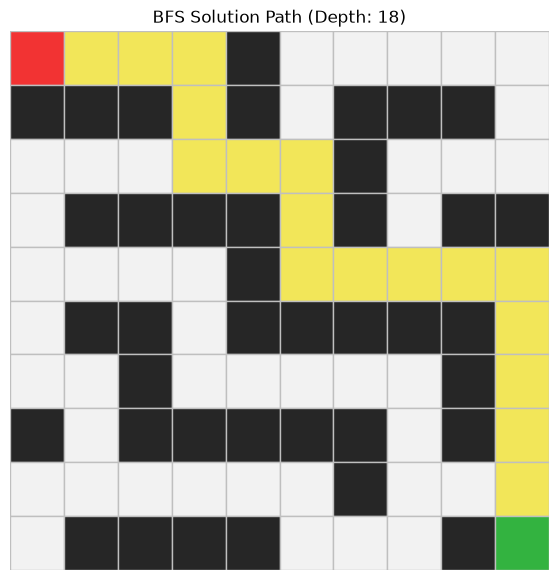

DFS found a solution with depth: 26
DFS expanded: 37 nodes
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (6, 1), (7, 1), (8, 1), (8, 2), (8, 3), (8, 4), (8, 5), (9, 5), (9, 6), (9, 7), (8, 7), (8, 8), (8, 9), (9, 9)]


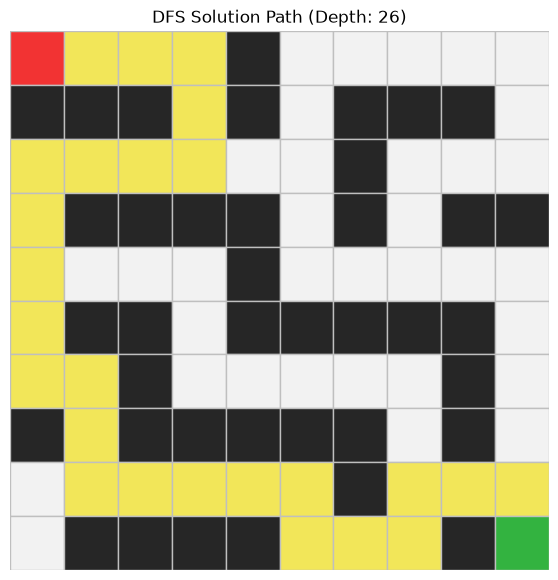


DETAILED COMPARISON

BFS:
  Status: success
  Solution depth: 18
  Solution cost: 18
  Nodes expanded: 50
  Max frontier/stack size: 5
  Reached states: 52
  Path length: 19
  Path: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3)]...


DFS:
  Status: success
  Solution depth: 26
  Solution cost: 26
  Nodes expanded: 37
  Max frontier/stack size: 4
  Reached states: 39
  Path length: 27
  Path: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3)]...


DLS:
  Status: cutoff
  Solution depth: None
  Solution cost: None
  Nodes expanded: 16
  Max frontier/stack size: 11
  Reached states: 0


IDS:
  Status: success
  Solution depth: 18
  Solution cost: 18
  Nodes expanded: 356
  Max frontier/stack size: 19
  Reached states: 0
  Path length: 19
  Path: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3)]...



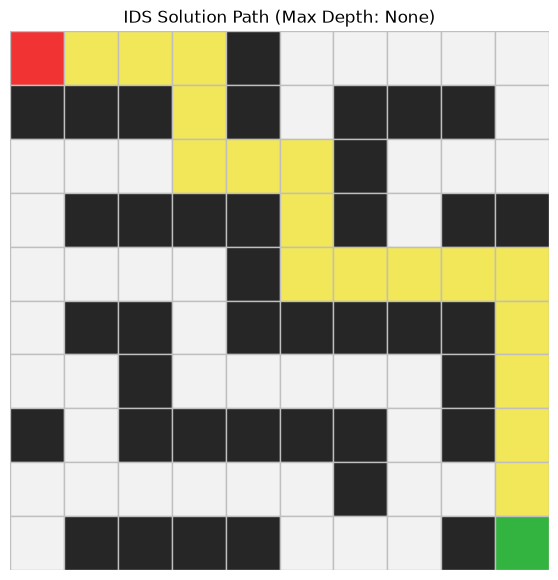


DLS WITH DIFFERENT DEPTH LIMITS

Limit 2:
  Status: cutoff
  Solution depth: None
  Nodes expanded: 2
 Reached limit without finding goal

Limit 5:
  Status: cutoff
  Solution depth: None
  Nodes expanded: 5
 Reached limit without finding goal

Limit 10:
  Status: cutoff
  Solution depth: None
  Nodes expanded: 16
 Reached limit without finding goal

Limit 15:
  Status: cutoff
  Solution depth: None
  Nodes expanded: 38
 Reached limit without finding goal

Limit 20:
  Status: success
  Solution depth: 18
  Nodes expanded: 63


SearchResult(algorithm='IDS', status='success', solution=Node(state=(9, 9), parent=Node(state=(8, 9), parent=Node(state=(7, 9), parent=Node(state=(6, 9), parent=Node(state=(5, 9), parent=Node(state=(4, 9), parent=Node(state=(4, 8), parent=Node(state=(4, 7), parent=Node(state=(4, 6), parent=Node(state=(4, 5), parent=Node(state=(3, 5), parent=Node(state=(2, 5), parent=Node(state=(2, 4), parent=Node(state=(2, 3), parent=Node(state=(1, 3), parent=Node(state=(0, 3), parent=Node(state=(0, 2), parent=Node(state=(0, 1), parent=Node(state=(0, 0), parent=None, action=None, path_cost=0, depth=0), action='RIGHT', path_cost=1, depth=1), action='RIGHT', path_cost=2, depth=2), action='RIGHT', path_cost=3, depth=3), action='DOWN', path_cost=4, depth=4), action='DOWN', path_cost=5, depth=5), action='RIGHT', path_cost=6, depth=6), action='RIGHT', path_cost=7, depth=7), action='DOWN', path_cost=8, depth=8), action='DOWN', path_cost=9, depth=9), action='RIGHT', path_cost=10, depth=10), action='RIGHT', pat

In [7]:
 #Step 1:to make sure the sample grid is defined:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)


#Step 2: running all algorithms on the sample map:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()
results = [
    bfs.search(problem),                    
    dfs.search(problem),                    
    dls.search(problem, limit=10),          
    ids.search(problem, max_depth=30),   
]

# Displaying the comparison table
print("=" * 70)
print("SEARCH ALGORITHM COMPARISON ON SAMPLE MAP")
print("=" * 70)
show_results(results)


#Step 3: visualizing the BFS Solution Path:
bfs_result = results[0]

if bfs_result.solution:
    print(f"BFS found a solution with depth: {bfs_result.solution_depth}")
    print(f"BFS expanded: {bfs_result.nodes_expanded} nodes")
    print(f"Path: {bfs_result.path}")
    
    plot_path(
        sample_grid,
        start,
        goal,
        path=bfs_result.path,
        title=f"BFS Solution Path (Depth: {bfs_result.solution_depth})",
    )
else:
    print("BFS did not find a solution!")

#Step 4: visualizing the DFS Solution Path:
dfs_result = results[1]

if dfs_result.solution:
    print(f"DFS found a solution with depth: {dfs_result.solution_depth}")
    print(f"DFS expanded: {dfs_result.nodes_expanded} nodes")
    print(f"Path: {dfs_result.path}")
    
    plot_path(
        sample_grid,
        start,
        goal,
        path=dfs_result.path,
        title=f"DFS Solution Path (Depth: {dfs_result.solution_depth})",
    )
else:
    print("DFS did not find a solution!")


#Step 5: Comparing all algorithms in detail:
print("\n" + "=" * 70)
print("DETAILED COMPARISON")
print("=" * 70)

for result in results:
    print(f"\n{result.algorithm}:")
    print(f"  Status: {result.status}")
    print(f"  Solution depth: {result.solution_depth}")
    print(f"  Solution cost: {result.solution_cost}")
    print(f"  Nodes expanded: {result.nodes_expanded}")
    print(f"  Max frontier/stack size: {result.max_frontier_size}")
    print(f"  Reached states: {result.reached_count}")
    
    if result.path:
        print(f"  Path length: {len(result.path)}")
        # to show first 5 steps
        print(f"  Path: {result.path[:5]}...")  
    print()
#Step 6: visualizing the DLS and IDS:
# 6.1 visualizing the DLS solution
dls_result = results[2]

if dls_result.solution:
    plot_path(
        sample_grid,
        start,
        goal,
        path=dls_result.path,
        title=f"DLS Solution Path (Limit: {dls_result.limit})",
    )

# 6.2 visualizing IDS solution: 
ids_result = results[3]

if ids_result.solution:
    plot_path(
        sample_grid,
        start,
        goal,
        path=ids_result.path,
        title=f"IDS Solution Path (Max Depth: {ids_result.limit})",
    )

#Step 7: testing the DLS with different limits
print("\n" + "=" * 70)
print("DLS WITH DIFFERENT DEPTH LIMITS")
print("=" * 70)

for limit in [2, 5, 10, 15, 20]:
    result = dls.search(problem, limit=limit)
    print(f"\nLimit {limit}:")
    print(f"  Status: {result.status}")
    print(f"  Solution depth: {result.solution_depth}")
    print(f"  Nodes expanded: {result.nodes_expanded}")
    
    if result.status == "cutoff":
        print(f" Reached limit without finding goal")

# Trying larger limit:
dls.search(problem, limit=30)  

# Trying larger max_depth:
ids.search(problem, max_depth=50)   

14. Create my Own Maps

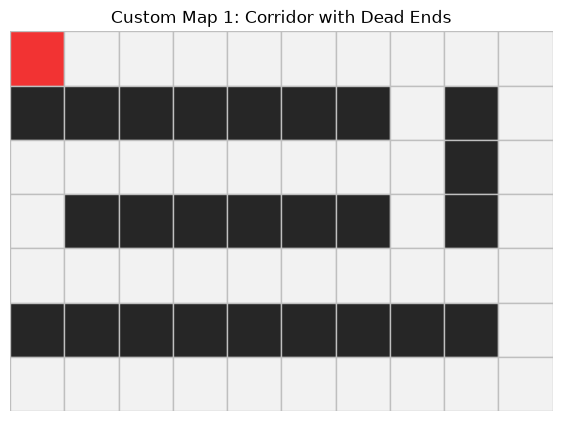


CUSTOM MAP 1: NARROW CORRIDOR WITH DEAD ENDS
INTERPRETATION - MAP 1:
This map has a long corridor with dead ends.
BFS will find the shortest path through the corridor.
DFS may waste time exploring dead ends before finding the path.
The deep corridor structure makes this interesting for DFS vs BFS comparison.


In [12]:
# TODO 10: creating my first custom map here:
custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (7, 9)

# Visualizing the map:
plot_path(custom_grid_1, custom_start_1, custom_goal_1, title="Custom Map 1: Corridor with Dead Ends")

# Running the algorithms on first custom map:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

print("\n" + "=" * 70)
print("CUSTOM MAP 1: NARROW CORRIDOR WITH DEAD ENDS")
print("=" * 70)
show_results(custom_results_1)

# Visualizing the BFS path on custom map 1
if custom_results_1[0].solution:
    plot_path(
        custom_grid_1,
        custom_start_1,
        custom_goal_1,
        path=custom_results_1[0].path,
        title="Map 1: BFS Solution Path (Shortest)",
    )

# Visualizing the DFS path on custom map 1
if custom_results_1[1].solution:
    plot_path(
        custom_grid_1,
        custom_start_1,
        custom_goal_1,
        path=custom_results_1[1].path,
        title="Map 1: DFS Solution Path (May Explore Dead Ends)",
    )

# Interpretation for Map 1
print("INTERPRETATION - MAP 1:")
print("This map has a long corridor with dead ends.")
print("BFS will find the shortest path through the corridor.")
print("DFS may waste time exploring dead ends before finding the path.")
print("The deep corridor structure makes this interesting for DFS vs BFS comparison.")

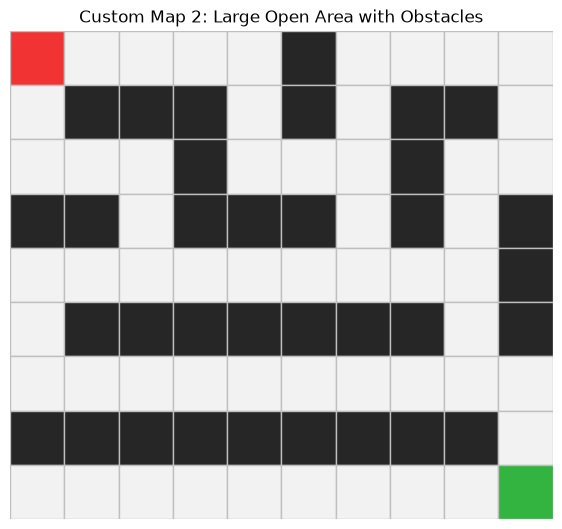


CUSTOM MAP 2: LARGE OPEN AREA WITH OBSTACLES


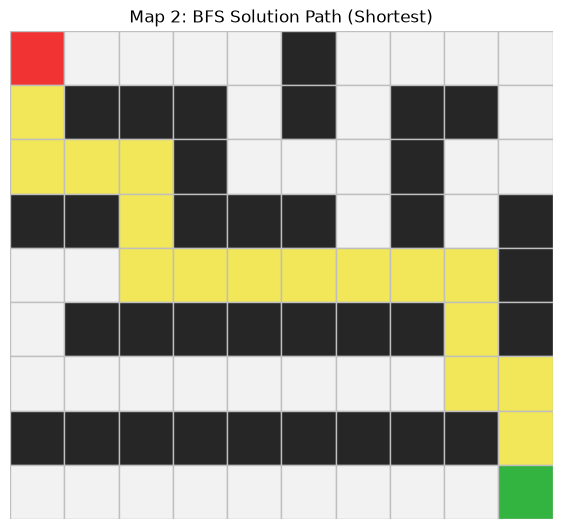

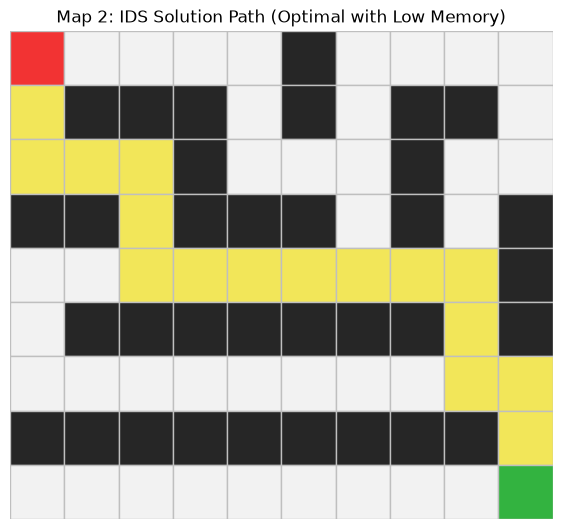

INTERPRETATION - MAP 2:
This is a larger 9x10 grid with multiple possible paths.
BFS will find the shortest path, exploring many states.
DFS may find a path but not necessarily the shortest.
IDS combines benefits of both: optimal path with low memory usage.


In [13]:
# TODO 11:creating my second custom map here:
custom_grid_2 = [
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (8, 9)

# Visualizing the map
plot_path(custom_grid_2, custom_start_2, custom_goal_2, title="Custom Map 2: Large Open Area with Obstacles")

# Running the algorithms on second custom map
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=30),
]

print("\n" + "=" * 70)
print("CUSTOM MAP 2: LARGE OPEN AREA WITH OBSTACLES")
print("=" * 70)
show_results(custom_results_2)

# Visualizing the BFS path on custom map 2
if custom_results_2[0].solution:
    plot_path(
        custom_grid_2,
        custom_start_2,
        custom_goal_2,
        path=custom_results_2[0].path,
        title="Map 2: BFS Solution Path (Shortest)",
    )

# Visualizing the IDS path on custom map 2
if custom_results_2[3].solution:
    plot_path(
        custom_grid_2,
        custom_start_2,
        custom_goal_2,
        path=custom_results_2[3].path,
        title="Map 2: IDS Solution Path (Optimal with Low Memory)",
    )

# Interpretation for Map 2
print("INTERPRETATION - MAP 2:")
print("This is a larger 9x10 grid with multiple possible paths.")
print("BFS will find the shortest path, exploring many states.")
print("DFS may find a path but not necessarily the shortest.")
print("IDS combines benefits of both: optimal path with low memory usage.")


15. Reflection Questions

15.1 Problem Formulation

1. A state in this lab, is a tuple (row, column) representing the drone's current position
2. An action is a movement in one of four directions which are: up, down,left, and right
3. The result function takes a state and an action, and returns the new state after applying that action
4. It is useful to separate the problem definition from the search algorithm because it allows the same search algorithms (BFS, DFS...etc) to work on any problem domain (grid problems, games...etc) without making any modification


15.2 BFS

1. BFS uses a FIFO queue to ensure nodes are explored in the order they are discovered
2. BFS finds the shortest path in terms of number of steps on the unweighted grid, because BFS explores all nodes at depth d before moving to depth d+1
3. The reached set in BFS prevents revisiting states, which avoids infinite loops and redundant work

15.3 DFS

1. DFS uses a stack to explore the most recently discovered node first
2. No, DFS is not guaranteed to find the shortest path. Because, it explores one path completely before trying another, meaning it does not compare paths or check if a shorter route exists
3. DFS stores one path at a time (low memory). BFS stores all nodes at the 
current level (can use lots of memory). So, DFS is better for memory-limited situations
4. DDFS performs badly when:
 - The search space is very deep or infinite 
 - The goal is shallow 
 - There is a large branching factor 
 - There are cycles 
 - You need the shortest path

15.4 DLS

1. When the depth limit is too small, The search stops before reaching then goal and returns "cutoff"
2. "Cutoff" means the search reached the maximum allowed depth without finding a solution
3. DLS is different from ordinary DFS, because it has a maximum depth limit, so it cannot go deeper than allowed
4. We use path-cycle checking in DLS to prevent loops without using too much memory

15.5 IDS

1. IDS repeats DLS with increasing limits to combine the benefits of BFS and DFS. It gradually explores deeper levels until it finds the goal
2. IDS can be complete even though DLS with a small limit is not, because it keeps increasing the limit until it reaches the goal's depth
3. IDS uses less memory than BFS, because it uses one path at a time instead of storing all nodes at the current level like BFS does
4. The cost of repeatedly searching from the root is re-exploring nodes at each iteration


15.6 Real-World Drone Context

1. In a real drone application, what might make one route safer or more practical than another are: weather (wind, rain), restricted zones, how much battery is left, avoiding people, staying connected to the controller, and avoiding obstacles like trees or buildings
2. I would choose BFS or IDS. Because both find the shortest path, and IDS uses less memory, which is important for drones
3. If I want to limit how deep the drone is allowed to search, i would choose Depth-Limited Search (DLS), because it stops at a predefined depth, and which is useful for battery-limited drones
4. The limitations that  this grid model have compared with real drone navigation is:
   -  2D vs 3D
   -  Discrete vs continuous movement
   -  Static vs dynamic obstacles
   -  No communications problems
   -  No battery or time constraints












